In [23]:
import pandas as pd
data = pd.read_csv('/Users/muhammadzuamaalamin/Documents/percobaancvd/datasetfix/heart_disease_new_dataset1.csv')
data

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_VEGRES1,_FRUTSU1,_VEGESU1,_FRTLT1A,_VEGLT1A,_FRT16A,_VEG23A,_FRUITE1,_VEGETE1,CVD_LABEL
0,1.0,1.0,b'01192021',b'01',b'19',b'2021',1100.0,b'2021000001',2.021000e+09,1.0,...,1.0,100.0,214.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
1,1.0,1.0,b'01212021',b'01',b'21',b'2021',1100.0,b'2021000002',2.021000e+09,1.0,...,1.0,100.0,128.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,CHD Only
2,1.0,1.0,b'01212021',b'01',b'21',b'2021',1100.0,b'2021000003',2.021000e+09,1.0,...,1.0,100.0,71.0,1.0,2.0,1.0,1.0,5.397605e-79,5.397605e-79,CHD Only
3,1.0,1.0,b'01172021',b'01',b'17',b'2021',1100.0,b'2021000004',2.021000e+09,1.0,...,1.0,114.0,165.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
4,1.0,1.0,b'01152021',b'01',b'15',b'2021',1100.0,b'2021000005',2.021000e+09,1.0,...,1.0,100.0,258.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,MI + Stroke
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438688,78.0,12.0,b'01062022',b'01',b'06',b'2022',1100.0,b'2021001381',2.021001e+09,NaN,...,1.0,157.0,393.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438689,78.0,12.0,b'01122022',b'01',b'12',b'2022',1100.0,b'2021001382',2.021001e+09,NaN,...,1.0,200.0,157.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438690,78.0,12.0,b'12212021',b'12',b'21',b'2021',1100.0,b'2021001383',2.021001e+09,NaN,...,1.0,200.0,143.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt
438691,78.0,12.0,b'01112022',b'01',b'11',b'2022',1100.0,b'2021001384',2.021001e+09,NaN,...,1.0,100.0,156.0,1.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,Healt


In [24]:
data.isnull().sum()

_STATE       0
FMONTH       0
IDATE        0
IMONTH       0
IDAY         0
            ..
_FRT16A      0
_VEG23A      0
_FRUITE1     0
_VEGETE1     0
CVD_LABEL    0
Length: 304, dtype: int64

In [25]:
data['CVD_LABEL'].value_counts()

CVD_LABEL
Healt                391852
Stroke Only           11518
CHD Only              11048
Heart Attack Only     10295
MI + CHD               8285
MI + Stroke            2137
All Three              2114
CHD + Stroke           1444
Name: count, dtype: int64

In [26]:
miss = data.isnull().mean().sort_values(ascending=False) * 100
miss

HAVECFS      100.000000
WORKCFS      100.000000
TOLDCFS      100.000000
COLGHOUS      99.993162
COLGSEX       99.993162
                ...    
_TOTINDA       0.000000
_HCVU652       0.000000
_HLTHPLN       0.000000
_MENT14D       0.000000
CVD_LABEL      0.000000
Length: 304, dtype: float64

In [27]:
high = (miss >= 25).sum()
high

165

In [28]:
# Hapus kolom dengan missing value >= 50%
threshold = 25
cols_to_drop = miss[miss > threshold].index
data1 = data.drop(columns=cols_to_drop)

print(f"Kolom yang dihapus ({len(cols_to_drop)}): {list(cols_to_drop)}")
print(f"Shape sebelum: {data.shape}")
print(f"Shape sesudah: {data1.shape}")

Kolom yang dihapus (165): ['HAVECFS', 'WORKCFS', 'TOLDCFS', 'COLGHOUS', 'COLGSEX', 'SIGMTES1', 'MEDSHEPB', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'VCLNTES1', 'SDNATES1', 'BLDSTFIT', 'CSRVCTL2', 'LASTSIG4', 'PCSTALK', 'PCPSARS2', 'PSATIME1', 'STOLTEST', 'CCLGHOUS', 'CDHELP', 'STOOLDN1', 'VIRCOLO1', 'SMALSTOL', 'PSATEST1', 'HPVADSHT', 'CSRVINST', 'LOADULK2', 'CDDISCUS', 'CDSOCIAL', 'CDASSIST', 'CDHOUSE', 'CSRVCLIN', 'CSRVDEIN', 'CSRVINSR', 'CSRVRTRN', 'CSRVSUM', 'CSRVDOC1', 'COLNTES1', 'CRVCLPAP', 'CRVCLHPV', 'CRVCLCNC', 'COLNSIGM', 'CASTHNO2', 'CSRVTRT3', 'HOWLONG', 'COLNCNCR', 'HADSIGM4', 'CSRVPAIN', 'HADHYST2', 'CERVSCRN', 'HADMAM', 'CNCRTYP1', 'CNCRAGE', 'CNCRDIFF', 'HAVEHEPB', 'TOLDHEPC', 'LCSNUMCG', 'LCSLAST', 'GUNLOAD', 'LCSFIRST', 'HPVADVC4', 'RSNMRJN2', 'USEMRJN3', 'SHINGLE2', 'TETANUS1', 'FEETCHK', 'DIABEDU', 'DIABEYE', 'EYEEXAM1', 'CHKHEMO3', 'DOCTDIAB', 'FEETCHK3', 'INSULIN1', 'BLDSUGAR', 'STOPSMK2', 'LCSCTSCN', 'FIREARM5', 'NUMPHON3', 'CIMEMLOS', 'CRGVALZD', 'DRADVISE', 'WTCHSA

In [29]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 139 entries, _STATE to CVD_LABEL
dtypes: float64(133), object(6)
memory usage: 465.2+ MB


In [30]:
# Cara 1 - Print list kolom yang dihapus
cols_to_drop = miss[miss >= 25].index
print(f"Kolom yang dihapus ({len(cols_to_drop)}):")
print(list(cols_to_drop))

Kolom yang dihapus (165):
['HAVECFS', 'WORKCFS', 'TOLDCFS', 'COLGHOUS', 'COLGSEX', 'SIGMTES1', 'MEDSHEPB', 'TRETHEPC', 'PRIRHEPC', 'HAVEHEPC', 'VCLNTES1', 'SDNATES1', 'BLDSTFIT', 'CSRVCTL2', 'LASTSIG4', 'PCSTALK', 'PCPSARS2', 'PSATIME1', 'STOLTEST', 'CCLGHOUS', 'CDHELP', 'STOOLDN1', 'VIRCOLO1', 'SMALSTOL', 'PSATEST1', 'HPVADSHT', 'CSRVINST', 'LOADULK2', 'CDDISCUS', 'CDSOCIAL', 'CDASSIST', 'CDHOUSE', 'CSRVCLIN', 'CSRVDEIN', 'CSRVINSR', 'CSRVRTRN', 'CSRVSUM', 'CSRVDOC1', 'COLNTES1', 'CRVCLPAP', 'CRVCLHPV', 'CRVCLCNC', 'COLNSIGM', 'CASTHNO2', 'CSRVTRT3', 'HOWLONG', 'COLNCNCR', 'HADSIGM4', 'CSRVPAIN', 'HADHYST2', 'CERVSCRN', 'HADMAM', 'CNCRTYP1', 'CNCRAGE', 'CNCRDIFF', 'HAVEHEPB', 'TOLDHEPC', 'LCSNUMCG', 'LCSLAST', 'GUNLOAD', 'LCSFIRST', 'HPVADVC4', 'RSNMRJN2', 'USEMRJN3', 'SHINGLE2', 'TETANUS1', 'FEETCHK', 'DIABEDU', 'DIABEYE', 'EYEEXAM1', 'CHKHEMO3', 'DOCTDIAB', 'FEETCHK3', 'INSULIN1', 'BLDSUGAR', 'STOPSMK2', 'LCSCTSCN', 'FIREARM5', 'NUMPHON3', 'CIMEMLOS', 'CRGVALZD', 'DRADVISE', 'WTCHSA

In [31]:
data1 = data1.drop(columns=['IDATE', 'IMONTH', 'IDAY', 'IYEAR','_STATE','FMONTH','DISPCODE','SEQNO','_PSU'])

In [32]:
# Cara 1 - Value counts semua kolom sekaligus
for col in data1.columns:
    print(f"\n{'='*50}")
    print(f"Kolom: {col}")
    print(data1[col].value_counts(dropna=False))


Kolom: SEXVAR
SEXVAR
2.0    234883
1.0    203810
Name: count, dtype: int64

Kolom: GENHLTH
GENHLTH
2.0    149112
3.0    137938
1.0     77741
4.0     54736
5.0     18005
7.0       788
9.0       369
NaN         4
Name: count, dtype: int64

Kolom: PHYSHLTH
PHYSHLTH
88.0    287796
30.0     29732
2.0      22220
1.0      17063
3.0      12868
5.0      11642
10.0      8595
77.0      7898
15.0      7623
4.0       6821
7.0       6695
20.0      4670
14.0      3994
6.0       1901
25.0      1866
99.0      1593
8.0       1254
21.0       927
12.0       813
28.0       671
9.0        302
29.0       279
18.0       253
16.0       222
17.0       158
27.0       155
13.0       126
22.0       120
11.0       119
26.0       108
24.0        98
23.0        65
19.0        43
NaN          3
Name: count, dtype: int64

Kolom: MENTHLTH
MENTHLTH
88.0    271161
30.0     24953
2.0      22717
5.0      19130
3.0      14567
10.0     14554
15.0     13475
1.0      13091
20.0      7993
7.0       7428
4.0       7419
77.0     

In [33]:
# Cara 4 - Dalam bentuk DataFrame (paling mudah dibaca)
pd.DataFrame({
    'Kolom': data1.columns,
    'Tipe Data': data1.dtypes.values,
    'Missing (%)': (data1.isnull().mean() * 100).round(2).values
})

,Kolom,Tipe Data,Missing (%)
0,SEXVAR,float64,0.0
1,GENHLTH,float64,0.0
2,PHYSHLTH,float64,0.0
3,MENTHLTH,float64,0.0
4,PRIMINSR,float64,0.0
...,...,...,...
125,_FRT16A,float64,0.0
126,_VEG23A,float64,0.0
127,_FRUITE1,float64,0.0
128,_VEGETE1,float64,0.0


In [34]:
severity_map = {
    'Healt'            : 0,  # Sehat
    'Stroke Only'       : 1,  # Level 1 → 1 kondisi
    'CHD Only'          : 1,  # Level 1 → 1 kondisi
    'Heart Attack Only' : 1,  # Level 1 → 1 kondisi
    'MI + CHD'          : 1,  # Level 2 → 2 kondisi
    'MI + Stroke'       : 1,  # Level 2 → 2 kondisi
    'CHD + Stroke'      : 1,  # Level 2 → 2 kondisi
    'All Three'         : 1,  # Level 3 → 3 kondisi
}

data1['CVD_SEVERITY'] = data1['CVD_LABEL'].map(severity_map)

# Verifikasi
print(data1['CVD_SEVERITY'].value_counts())
print(f"\nTotal : {len(data1):,}")

CVD_SEVERITY
0    391852
1     46841
Name: count, dtype: int64

Total : 438,693


In [35]:
data1 = data1.drop(columns=['_VEGRES1','_FRTRES1','_MISVEG1','_MISFRT1','CVD_LABEL'])
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438693 entries, 0 to 438692
Columns: 126 entries, SEXVAR to CVD_SEVERITY
dtypes: float64(125), int64(1)
memory usage: 421.7 MB


In [36]:
# Cek null semua kolom
null_summary = pd.DataFrame({
    'null_count': data1.isnull().sum(),
    'null_percent': (data1.isnull().sum() / len(data1) * 100).round(2)
}).sort_values('null_percent', ascending=False)

print(null_summary[null_summary['null_count'] > 0])

          null_count  null_percent
CHOLMED3       61571         14.04
_RFCHOL3       61151         13.94
TOLDHI3        60836         13.87
_VEGESU1       60127         13.71
_FRUTSU1       51087         11.65
...              ...           ...
PHYSHLTH           3          0.00
HAVARTH5           3          0.00
EDUCA              5          0.00
RENTHOM1           8          0.00
GENHLTH            4          0.00

[75 rows x 2 columns]


In [37]:
data_new = data1.dropna()
print(f"Sebelum : {len(data1)} baris")
print(f"Sesudah : {len(data_new)} baris")
print(f"Terhapus: {len(data1) - len(data_new)} baris")

Sebelum : 438693 baris
Sesudah : 289586 baris
Terhapus: 149107 baris


In [38]:
# Pastikan semua kolom ini tidak ada
forbidden = ['_MICHD', 'CVDSTRK3', 'CVDCRHD4', 'CVDINFR4']
data_new = data_new.drop(columns=forbidden)
for col in forbidden:
    if col in data_new.columns:
        print(f"⚠️  MASIH ADA: {col}")
    else:
        print(f"✅ Sudah dihapus: {col}")

✅ Sudah dihapus: _MICHD
✅ Sudah dihapus: CVDSTRK3
✅ Sudah dihapus: CVDCRHD4
✅ Sudah dihapus: CVDINFR4


In [39]:
# ============================================================
# SUBSAMPLE — ambil N baris random dari seluruh data
# ============================================================

SAMPLE_SIZE = 50_000   # ← ganti sesuai kebutuhan

data_sampled = data_new.sample(n=SAMPLE_SIZE, random_state=42)

print("Distribusi setelah sampling:")
print(data_sampled['CVD_SEVERITY'].value_counts().sort_index())

# ── Split seperti biasa dari data yang sudah disubsample ────
X = data_sampled.drop(columns=['CVD_SEVERITY'])
y = data_sampled['CVD_SEVERITY']


Distribusi setelah sampling:
CVD_SEVERITY
0    44080
1     5920
Name: count, dtype: int64


In [40]:
# X = data_new.drop(columns=['CVD_SEVERITY'])
# y = data_new['CVD_SEVERITY']

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [44]:
X.shape

(50000, 121)

In [45]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,recall_score

# Hitung scale_pos_weight untuk class imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Training model
model = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = 'logloss',
    random_state     = 42
)

model.fit(X_train, y_train)

# %%
# Evaluasi
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Sehat', 'CVD']))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       Sehat       0.96      0.78      0.86      8816
         CVD       0.31      0.75      0.44      1184

    accuracy                           0.77     10000
   macro avg       0.63      0.76      0.65     10000
weighted avg       0.88      0.77      0.81     10000

AUC-ROC: 0.8423

Confusion Matrix:
[[6860 1956]
 [ 300  884]]


## Feature Selection

Top 20 Feature Importance:
     feature  importance
0   CHOLMED3    0.229503
1   _RFHYPE6    0.063826
2   DIFFWALK    0.055792
3    EMPLOY1    0.054386
4    GENHLTH    0.030534
5    BPHIGH6    0.022098
6     _AGE80    0.013317
7   _AGEG5YR    0.012952
8       _SEX    0.012354
9   DIABETE4    0.012279
10  CHCCOPD3    0.011971
11  _HCVU652    0.011598
12  PNEUVAC4    0.010770
13  _LMTWRK3    0.010488
14  _SMOKER3    0.010347
15  _LMTACT3    0.009971
16    SEXVAR    0.009146
17  SMOKE100    0.008907
18  PERSDOC3    0.008567
19    DECIDE    0.008469


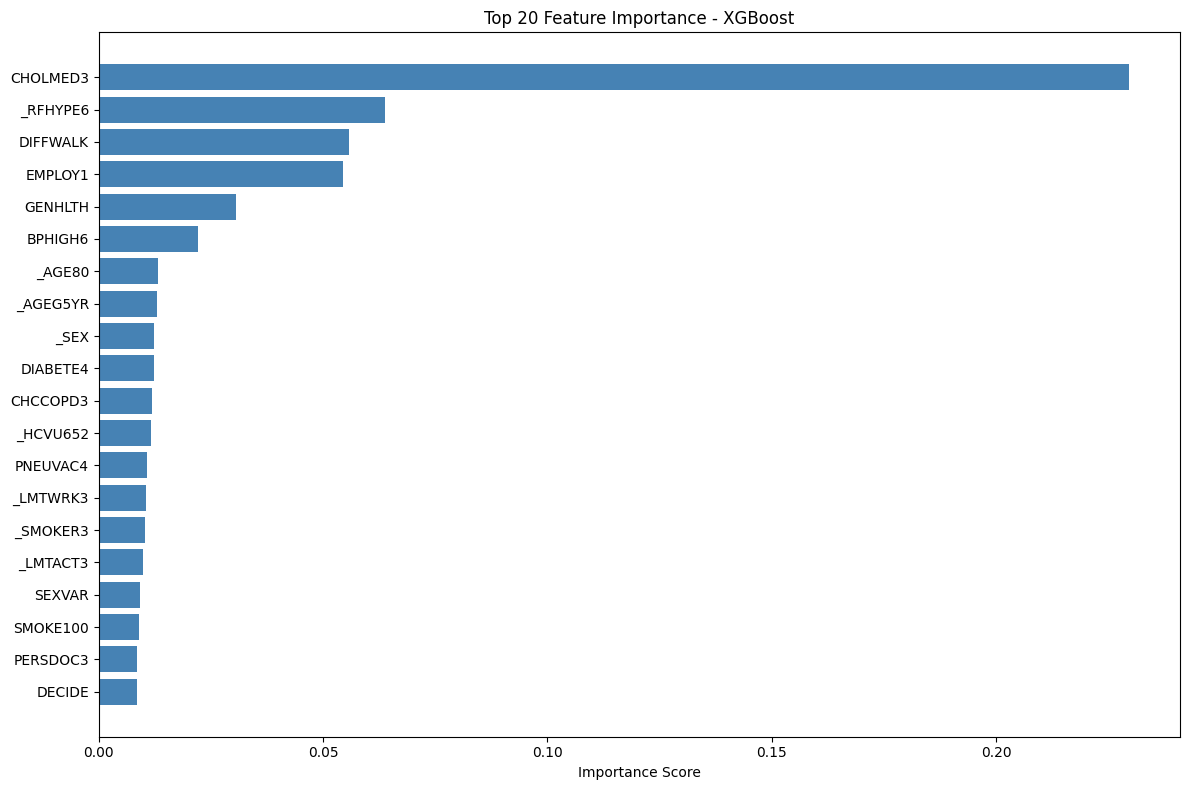

In [46]:
import matplotlib.pyplot as plt
# ── 1. Feature Importance dari model XGBoost yang sudah ditraining ──
importances = model.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 20 Feature Importance:")
print(feat_imp_df.head(20))

# %%
# ── 2. Plot Feature Importance ──
plt.figure(figsize=(12, 8))
top_n = 20
plt.barh(
    feat_imp_df['feature'][:top_n][::-1],
    feat_imp_df['importance'][:top_n][::-1],
    color='steelblue'
)
plt.xlabel('Importance Score')
plt.title(f'Top {top_n} Feature Importance - XGBoost')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from tqdm import tqdm
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# ── 1. Definisi desil & resamplers ──────────────────────────────────────────
desils = [1, 2, 3, 4, 5, 6, 7, 8, 9]

resamplers = {
    'scale_pos_weight' : None,
    'SMOTE'            : SMOTE(random_state=42),
    'ADASYN'           : ADASYN(random_state=42),
    'SMOTETomek'       : SMOTETomek(random_state=42),
    'SMOTEENN'         : SMOTEENN(random_state=42),
}

# ── 2. Loop desil × resampler ────────────────────────────────────────────────
results_all = {}
N_total = len(feat_imp_df)

outer_bar = tqdm(desils, desc="Desil", position=0)

for D in outer_bar:
    N_FEATURES = int(np.ceil(N_total * D / 10))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_d = X_train[selected_features]
    X_test_d  = X_test[selected_features]

    outer_bar.set_postfix({'fitur': N_FEATURES})

    inner_bar = tqdm(resamplers.items(), desc=f"  Resampler (D={D})", position=1, leave=False)

    for resampler_name, sampler in inner_bar:
        inner_bar.set_postfix({'method': resampler_name})

        if sampler is None:
            X_res, y_res = X_train_d, y_train
            spw = (y_train == 0).sum() / (y_train == 1).sum()
        else:
            X_res, y_res = sampler.fit_resample(X_train_d, y_train)
            spw = 1.0

        xgb_model_d = XGBClassifier(
            n_estimators     = 300,
            max_depth        = 6,
            learning_rate    = 0.05,
            subsample        = 0.8,
            colsample_bytree = 0.8,
            scale_pos_weight = spw,
            eval_metric      = 'logloss',
            random_state     = 42,
            n_jobs           = -1
        )
        xgb_model_d.fit(X_res, y_res)

        y_pred = xgb_model_d.predict(X_test_d)
        y_prob = xgb_model_d.predict_proba(X_test_d)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        key = f'D{D}_{resampler_name}'
        results_all[key] = {
            'Desil'        : D,
            'N Fitur'      : N_FEATURES,
            'Resampler'    : resampler_name,
            'Recall CVD'   : report['1']['recall'],
            'Precision CVD': report['1']['precision'],
            'F1 CVD'       : report['1']['f1-score'],
            'F1 Macro'     : report['macro avg']['f1-score'],
            'Accuracy'     : report['accuracy'],
            'AUC'          : roc_auc_score(y_test, y_prob)
        }

# ── 3. Tabel hasil ───────────────────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
results_df[['Desil', 'N Fitur']] = results_df[['Desil', 'N Fitur']].astype(int)

print("\n── Perbandingan Semua Kombinasi (sort by Recall CVD) ──")
print(results_df.sort_values('Recall CVD', ascending=False).to_string())

best = results_df.sort_values('Recall CVD', ascending=False).iloc[0]
print(f"\n✅ Kombinasi terbaik:")
print(f"   Desil      : {best['Desil']} ({int(best['Desil'])*10}% fitur teratas)")
print(f"   N Fitur    : {best['N Fitur']}")
print(f"   Resampler  : {best['Resampler']}")
print(f"   Recall CVD : {best['Recall CVD']}")
# print(f"   F1 Macro   : {best['F1 Macro']}")
# print(f"   AUC        : {best['AUC']}")

Desil: 100%|██████████| 10/10 [02:25<00:00, 14.58s/it, fitur=121]


── Perbandingan Semua Kombinasi (sort by Recall CVD) ──
                      Desil  N Fitur         Resampler Recall CVD Precision CVD    F1 CVD  F1 Macro Accuracy       AUC
D1_scale_pos_weight       1       13  scale_pos_weight   0.784628       0.29223  0.425854  0.632828   0.7495  0.837501
D2_scale_pos_weight       2       25  scale_pos_weight   0.771959      0.308471  0.440801   0.64726   0.7681  0.841955
D3_scale_pos_weight       3       37  scale_pos_weight   0.753378      0.312873  0.442131  0.650568   0.7749  0.845773
D4_scale_pos_weight       4       49  scale_pos_weight   0.738176      0.317357   0.44388  0.653767    0.781  0.844826
D5_scale_pos_weight       5       61  scale_pos_weight   0.733108      0.324244  0.449624  0.658978   0.7875  0.842563
D7_scale_pos_weight       7       85  scale_pos_weight   0.715372      0.328295  0.450053  0.661279    0.793  0.842907
D10_scale_pos_weight     10      121  scale_pos_weight   0.712838      0.326878  0.448221  0.660109   0.7922  


Skenario : D1_scale_pos_weight | 13 fitur


D1_scale_pos_weight: 100%|██████████| 8/8 [00:15<00:00,  1.91s/it]



Skenario : D2_SMOTEENN | 25 fitur


D2_SMOTEENN: 100%|██████████| 8/8 [01:03<00:00,  7.98s/it]



── Perbandingan Semua Skenario × Model (sort by Recall CVD) ──
                                                   Skenario               Model Recall CVD Precision CVD    F1 CVD  F1 Macro Accuracy       AUC
D2_SMOTEENN_LogisticRegression                  D2_SMOTEENN  LogisticRegression   0.880912      0.247156   0.38601  0.579344   0.6682  0.839253
D2_SMOTEENN_ExtraTrees                          D2_SMOTEENN          ExtraTrees   0.876689      0.225799  0.359107   0.54927   0.6295  0.829521
D1_scale_pos_weight_ExtraTrees          D1_scale_pos_weight          ExtraTrees   0.833615       0.25663  0.392445  0.594152   0.6944  0.831736
D1_scale_pos_weight_RandomForest        D1_scale_pos_weight        RandomForest   0.826858      0.279714  0.418019  0.620017   0.7274  0.840182
D1_scale_pos_weight_LightGBM            D1_scale_pos_weight            LightGBM   0.798986      0.291167  0.426799  0.631785   0.7459  0.839672
D2_SMOTEENN_RandomForest                        D2_SMOTEENN        Rando

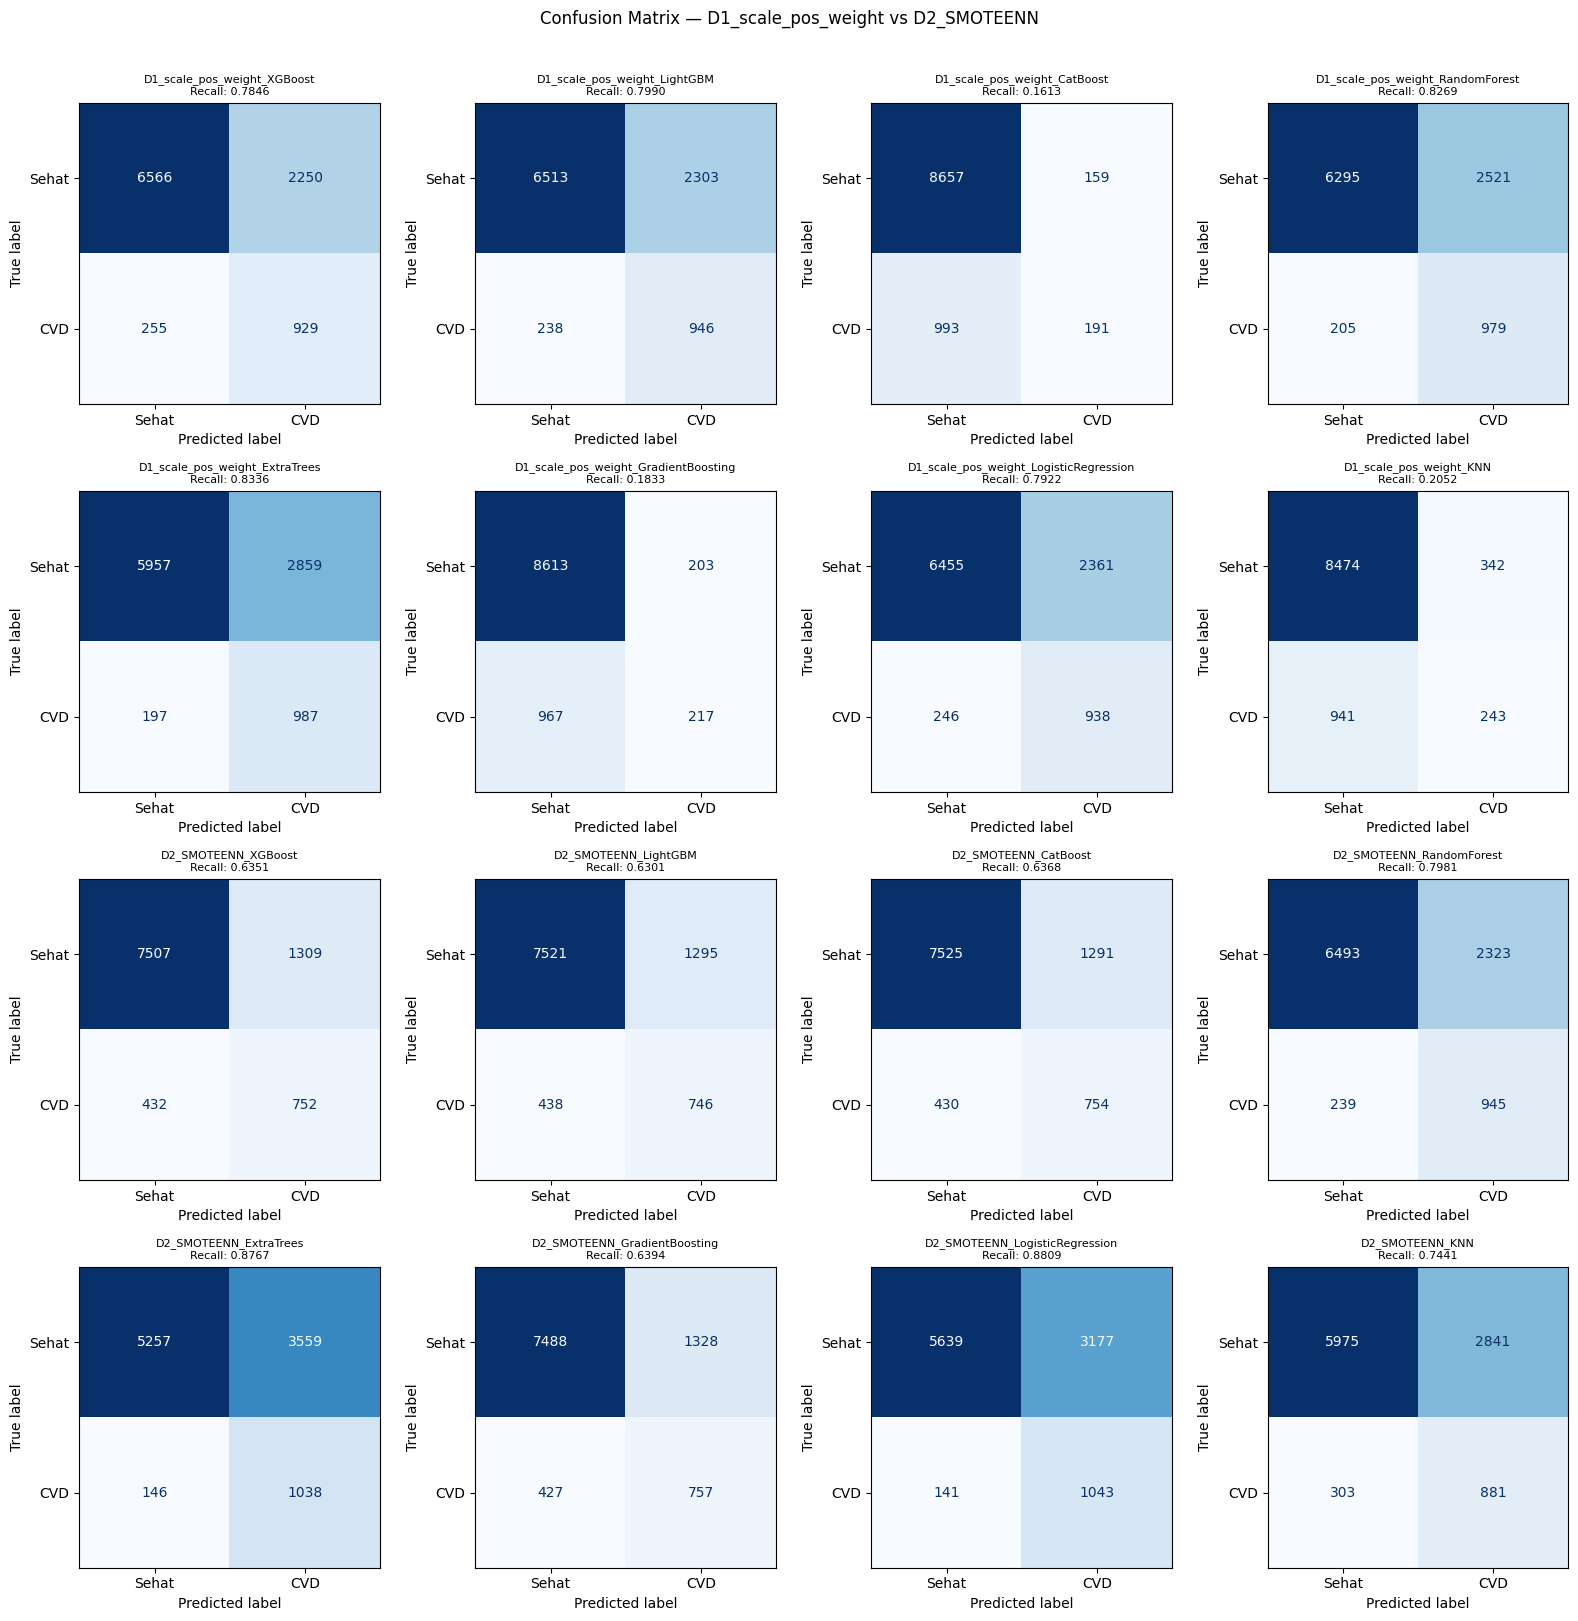

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# ── Konfigurasi 2 skenario terbaik ──────────────────────────
scenarios = {
    'D1_scale_pos_weight': {
        'desil'     : 1,
        'resampler' : None,
    },
    'D2_SMOTEENN': {
        'desil'     : 2,
        'resampler' : SMOTEENN(random_state=42),
    },
}

# ── Definisi model ───────────────────────────────────────────
models = {
    'XGBoost'           : XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                         subsample=0.8, colsample_bytree=0.8,
                                         eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM'          : LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost'          : CatBoostClassifier(iterations=300, depth=6, learning_rate=0.05,
                                              random_state=42, verbose=0),
    'RandomForest'      : RandomForestClassifier(n_estimators=300, max_depth=6,
                                                  random_state=42, n_jobs=-1),
    'ExtraTrees'        : ExtraTreesClassifier(n_estimators=300, max_depth=6,
                                                random_state=42, n_jobs=-1),
    'GradientBoosting'  : GradientBoostingClassifier(n_estimators=300, max_depth=6,
                                                      learning_rate=0.05, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'KNN'               : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

# ── Loop skenario × model ────────────────────────────────────
results_all  = {}
conf_matrices = {}

for sc_name, sc_cfg in scenarios.items():
    N_FEATURES        = int(np.ceil(N_total * sc_cfg['desil'] / 10))
    selected_features = feat_imp_df['feature'].head(N_FEATURES).tolist()

    X_train_sc = X_train[selected_features]
    X_test_sc  = X_test[selected_features]

    if sc_cfg['resampler'] is None:
        X_res, y_res = X_train_sc, y_train
        spw = (y_train == 0).sum() / (y_train == 1).sum()
    else:
        X_res, y_res = sc_cfg['resampler'].fit_resample(X_train_sc, y_train)
        spw = 1.0

    print(f"\n{'='*55}")
    print(f"Skenario : {sc_name} | {N_FEATURES} fitur")
    print(f"{'='*55}")

    for model_name, clf in tqdm(models.items(), desc=sc_name):
        # Set scale_pos_weight khusus XGBoost & LightGBM
        if hasattr(clf, 'scale_pos_weight'):
            clf.set_params(scale_pos_weight=spw)
        if hasattr(clf, 'class_weight'):
            clf.set_params(class_weight='balanced' if spw > 1 else None)

        clf.fit(X_res, y_res)

        y_pred = clf.predict(X_test_sc)
        y_prob = clf.predict_proba(X_test_sc)[:, 1]
        report = classification_report(y_test, y_pred, output_dict=True)

        key = f"{sc_name}_{model_name}"
        results_all[key] = {
            'Skenario'      : sc_name,
            'Model'         : model_name,
            'Recall CVD'    : report['1']['recall'],
            'Precision CVD' : report['1']['precision'],
            'F1 CVD'        : report['1']['f1-score'],
            'F1 Macro'      : report['macro avg']['f1-score'],
            'Accuracy'      : report['accuracy'],
            'AUC'           : roc_auc_score(y_test, y_prob)
        }
        conf_matrices[key] = confusion_matrix(y_test, y_pred)

# ── Tabel hasil ──────────────────────────────────────────────
results_df = pd.DataFrame(results_all).T.round(4)
print("\n── Perbandingan Semua Skenario × Model (sort by Recall CVD) ──")
print(results_df.sort_values('Recall CVD', ascending=False).to_string())

best = results_df.sort_values('Recall CVD', ascending=False).iloc[0]
print(f"\n✅ Terbaik : {best.name}")
print(f"   Skenario   : {best['Skenario']}")
print(f"   Model      : {best['Model']}")
print(f"   Recall CVD : {best['Recall CVD']}")
print(f"   F1 Macro   : {best['F1 Macro']}")
print(f"   AUC        : {best['AUC']}")

# ── Confusion Matrix ─────────────────────────────────────────
n_total = len(conf_matrices)
ncols   = 4
nrows   = int(np.ceil(n_total / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
axes = axes.flatten()

for i, (key, cm) in enumerate(conf_matrices.items()):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sehat', 'CVD'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f"{key}\nRecall: {results_all[key]['Recall CVD']:.4f}", fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrix — D1_scale_pos_weight vs D2_SMOTEENN', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()